In [879]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import platform
from pathlib import Path
from datetime import datetime
import time
import joblib


%pip install seaborn
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from fastapi import FastAPI, HTTPException
from fastapi.testclient import TestClient
from pydantic import BaseModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from fastapi.testclient import TestClient
from app import app

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import plot_tree,DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [880]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [881]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
student_performance = fetch_ucirepo(id=320) 
  
# data (as pandas dataframes) 
X = student_performance.data.features 
y = student_performance.data.targets 
  
# metadata 
print(student_performance.metadata) 
  
# variable information 
print(student_performance.variables)

{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [882]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [883]:
y.head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [884]:
y

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13
...,...,...,...
644,10,11,10
645,15,15,16
646,11,12,9
647,10,10,10


In [885]:
X.shape


(649, 30)

In [886]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [887]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


In [888]:
X.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
dtype: int64

In [889]:
X.duplicated().sum()

np.int64(0)

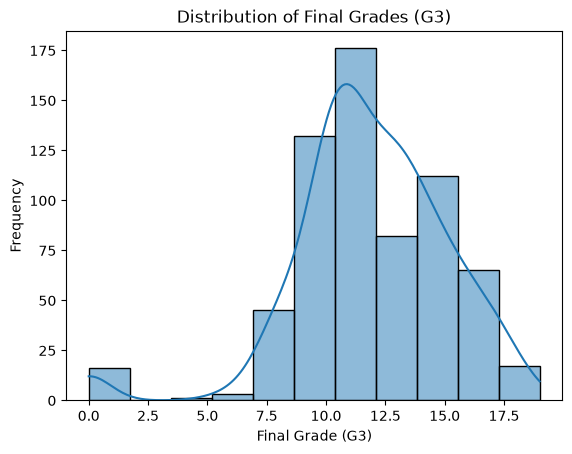

In [890]:
sns.histplot(y['G3'],bins=11, kde=True)

plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

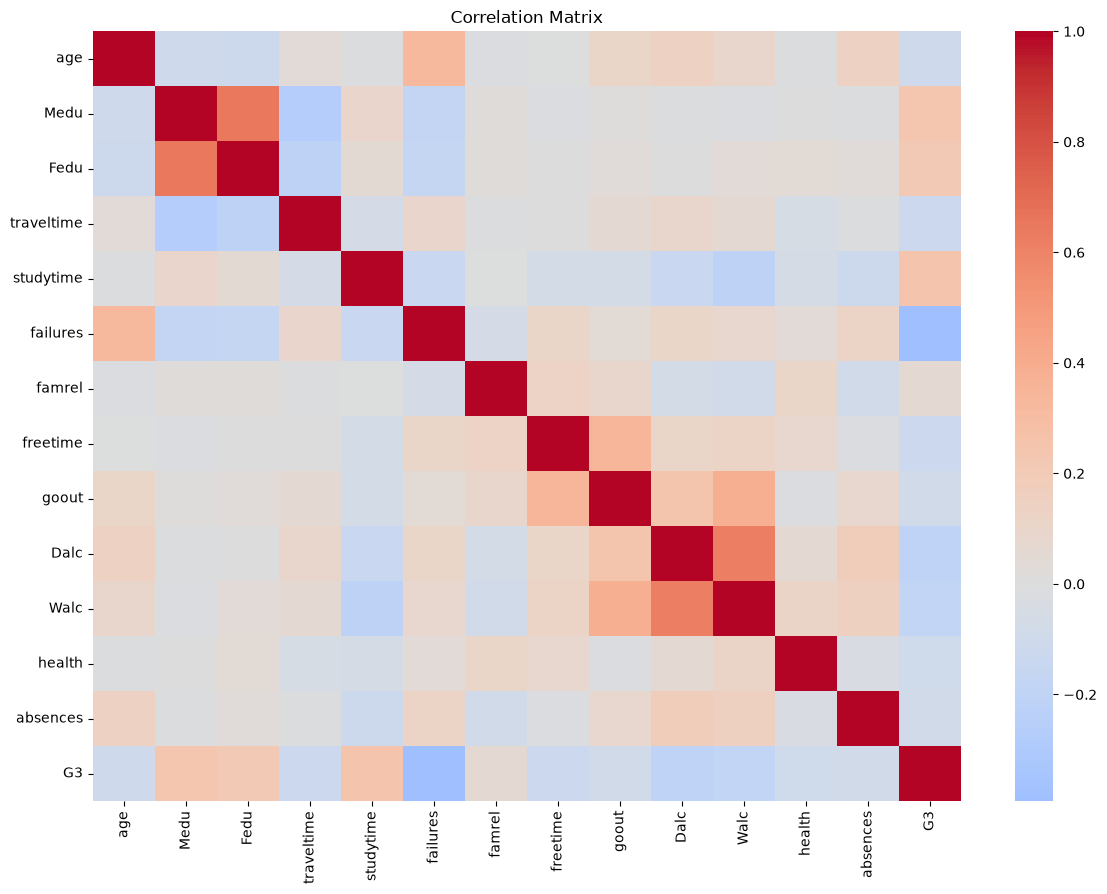

In [891]:
data = X.copy()
data['G3'] = y['G3']

correlation = data.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, cmap='coolwarm', center=0)

plt.title('Correlation Matrix')
plt.show()

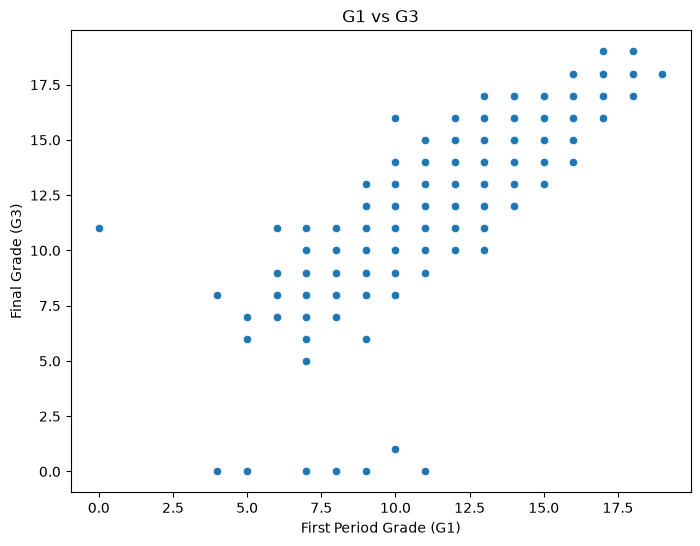

In [892]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y['G1'],
    y=y['G3']
)

plt.title('G1 vs G3')
plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.show()

Handle missing values

In [893]:

for column in data.columns:
    if data[column].dtype == 'object' or data[column].dtype == 'string':
        data[column] = data[column].fillna(data[column].mode()[0])
    else:
        data[column] = data[column].fillna(data[column].median())

print("\nMissing values after handling:")
print(data.isnull().sum())


Missing values after handling:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G3            0
dtype: int64


In [894]:
X = data.drop('G3', axis=1)
y = data['G3']

X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:")
print(X_encoded.shape)

print("\nEncoded data:")
print(X_encoded.head())

Shape after encoding:
(649, 39)

Encoded data:
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  ac

In [895]:
X_encoded.shape

(649, 39)

In [896]:
X_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


Normalize numirical features

In [897]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns
)

print(X_scaled.head())

        age      Medu      Fedu  traveltime  studytime  failures    famrel  \
0  1.031695  1.310216  1.540715    0.576718   0.083653 -0.374305  0.072606   
1  0.210137 -1.336039 -1.188832   -0.760032   0.083653 -0.374305  1.119748   
2 -1.432980 -1.336039 -1.188832   -0.760032   0.083653 -0.374305  0.072606   
3 -1.432980  1.310216 -0.278983   -0.760032   1.290114 -0.374305 -0.974536   
4 -0.611422  0.428131  0.630866   -0.760032   0.083653 -0.374305  0.072606   

   freetime     goout      Dalc  ...  guardian_mother  guardian_other  \
0 -0.171647  0.693785 -0.543555  ...         0.652973       -0.259681   
1 -0.171647 -0.157380 -0.543555  ...        -1.531457       -0.259681   
2 -0.171647 -1.008546  0.538553  ...         0.652973       -0.259681   
3 -1.123771 -1.008546 -0.543555  ...         0.652973       -0.259681   
4 -0.171647 -1.008546 -0.543555  ...        -1.531457       -0.259681   

   schoolsup_yes  famsup_yes  paid_yes  activities_yes  nursery_yes  \
0       2.923032   -1

Create averrage previous grades

In [898]:
original_targets = student_performance.data.targets
data['G1'] = original_targets['G1']
data['G2'] = original_targets['G2']
data['Average_Previous_Grades'] = data[['G1', 'G2']].mean(axis=1)

print(data[['G1', 'G2', 'Average_Previous_Grades']].head())

   G1  G2  Average_Previous_Grades
0   0  11                      5.5
1   9  11                     10.0
2  12  13                     12.5
3  14  14                     14.0
4  11  13                     12.0


Feature selection

In [899]:
y_class = (data['G3'] >= 10).astype(int)

X = data.drop('G3', axis=1)

X_encoded = pd.get_dummies(X, drop_first=True)

In [900]:
selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(X_encoded, y_class)

selected_features = X_encoded.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Medu', 'Fedu', 'studytime', 'failures', 'G1', 'G2',
       'Average_Previous_Grades', 'school_MS', 'address_U', 'higher_yes'],
      dtype='str')


## **Logistic_Regression**

In [901]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (519, 10)
Testing shape: (130, 10)


In [902]:
model = LogisticRegression(random_state=42)

In [903]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [904]:
y_pred_1 = model.predict(X_test)

In [905]:
acc=accuracy_score(y_test,y_pred_1)
print(f"Accuracy with Logistic Regression: {acc*100:.2f}%")

Accuracy with Logistic Regression: 90.00%


In [906]:
accuracy = accuracy_score(y_test, y_pred_1)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_1))

Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.70      0.68        20
           1       0.94      0.94      0.94       110

    accuracy                           0.90       130
   macro avg       0.81      0.82      0.81       130
weighted avg       0.90      0.90      0.90       130



## **Decision_Tree**

In [907]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [908]:
y_pred_2 = decision_tree.predict(X_test)

In [909]:
acc=accuracy_score(y_test,y_pred_2)
print(f'Accuracy with decision tree: {acc*100:.2f}%')

Accuracy with decision tree: 87.69%


In [910]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_2))


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        20
           1       0.93      0.93      0.93       110

    accuracy                           0.88       130
   macro avg       0.76      0.76      0.76       130
weighted avg       0.88      0.88      0.88       130



In [911]:
print(f"Tree Depth: {decision_tree.get_depth()}")
print(f"Leaves: {decision_tree.get_n_leaves()}")

Tree Depth: 11
Leaves: 51


importance feature 

In [912]:
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
6  Average_Previous_Grades    0.686465
2                studytime    0.075150
1                     Fedu    0.063117
0                     Medu    0.042346
7                school_MS    0.041132
5                       G2    0.027699
8                address_U    0.023018
3                 failures    0.022768
4                       G1    0.011315
9               higher_yes    0.006990


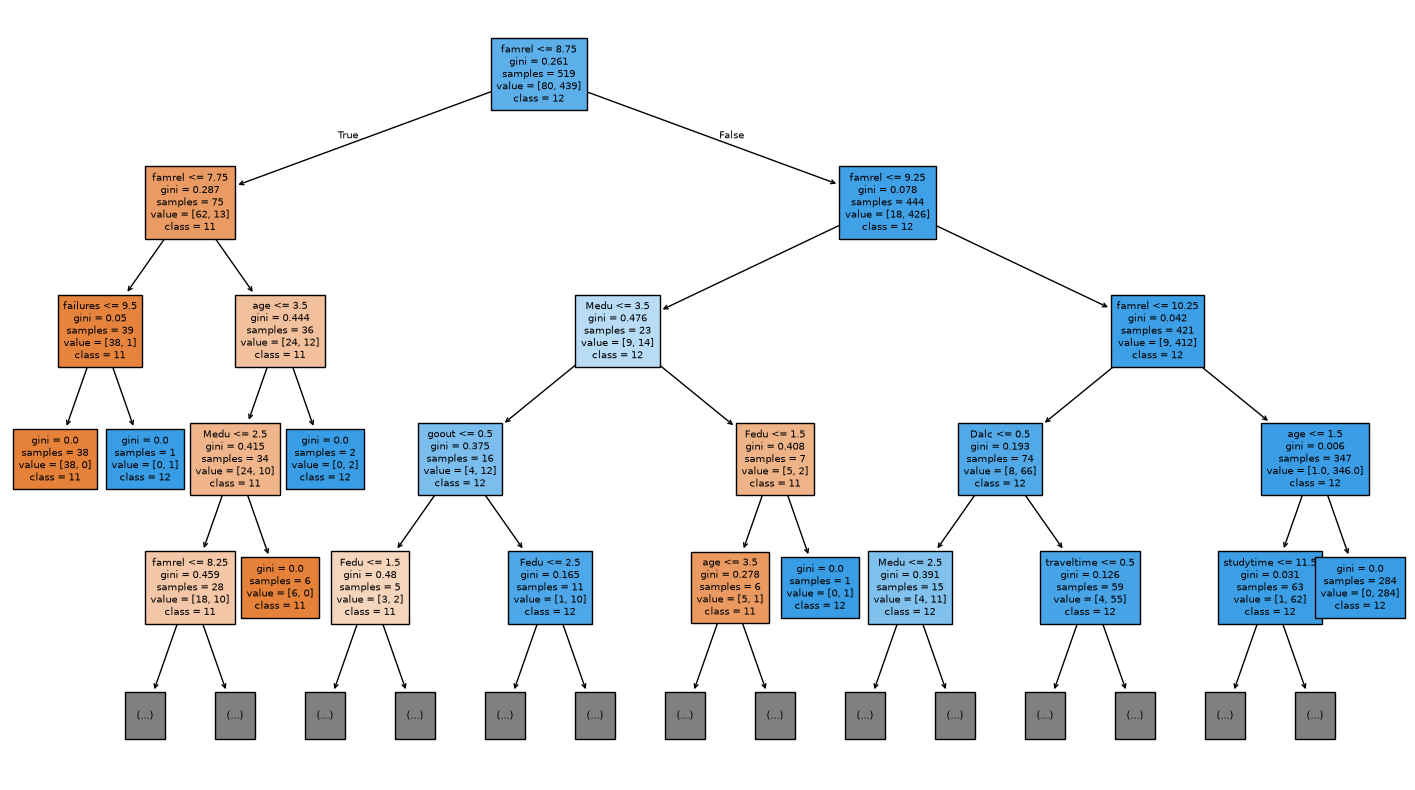

In [913]:
plt.figure(figsize=(18,10))
plot_tree(
    decision_tree,
    feature_names=X_encoded.columns.tolist(),
    class_names=y.unique().astype(str).tolist(),
    filled=True,
    fontsize=7,
    max_depth=4
)
plt.show()

In [914]:
accuracy = accuracy_score(y_test, y_pred_2)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_2))

Accuracy: 0.8769

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        20
           1       0.93      0.93      0.93       110

    accuracy                           0.88       130
   macro avg       0.76      0.76      0.76       130
weighted avg       0.88      0.88      0.88       130



## **SHAP, optional**

In [915]:
native_importance = pd.DataFrame({
    'Features': selected_features,
    'Importance': decision_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

native_importance.head(10)

,Features,Importance
6,Average_Previous_Grades,0.686465
2,studytime,0.075150
1,Fedu,0.063117
0,Medu,0.042346
7,school_MS,0.041132
5,G2,0.027699
8,address_U,0.023018
3,failures,0.022768
4,G1,0.011315
9,higher_yes,0.006990


In [916]:
native_importance.head(10)
#دي كدا global

,Features,Importance
6,Average_Previous_Grades,0.686465
2,studytime,0.075150
1,Fedu,0.063117
0,Medu,0.042346
7,school_MS,0.041132
5,G2,0.027699
8,address_U,0.023018
3,failures,0.022768
4,G1,0.011315
9,higher_yes,0.006990


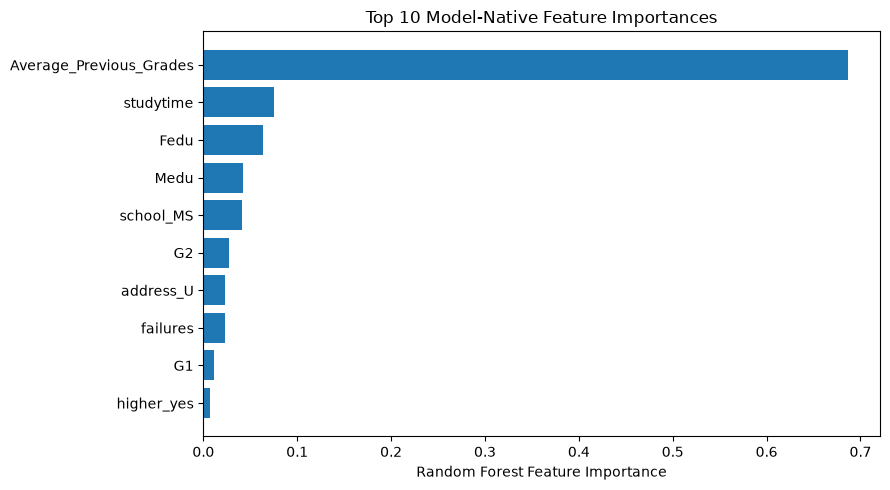

In [917]:
plt.figure(figsize=(9, 5))

plt.barh(
    native_importance['Features'].head(10)[::-1],
    native_importance['Importance'].head(10)[::-1]
    )

plt.xlabel("Random Forest Feature Importance")

plt.title("Top 10 Model-Native Feature Importances")

plt.tight_layout()

plt.show()

In [918]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    decision_tree,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=1
)

perm_df = pd.DataFrame({
    'Features': selected_features,
    'Importance_mean': perm_result.importances_mean,
    'Importance_std': perm_result.importances_std
}).sort_values(by='Importance_mean', ascending=False)

perm_df = pd.DataFrame({
    'Features': selected_features,
    'Importance_mean': perm_result.importances_mean,
    'Importance_std': perm_result.importances_std
}).sort_values(by='Importance_mean', ascending=False)

In [919]:
perm_df.head()

,Features,Importance_mean,Importance_std
6,Average_Previous_Grades,0.106154,0.018301
5,G2,0.033077,0.011691
1,Fedu,0.016923,0.009608
7,school_MS,0.010769,0.009231
4,G1,0.008462,0.007654


In [920]:

x_train_numeric = X_train.astype(float)
x_test_numeric = X_test.astype(float)

%pip install shap
import shap

explainer = shap.Explainer(
    decision_tree,
    x_train_numeric,
    feature_names=selected_features
)

shap_values = explainer(
    x_test_numeric,
    check_additivity=False
)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Background dataset has 519 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=519 when initializing the masker.


Note: you may need to restart the kernel to use updated packages.


In [921]:
shap_values.shape

(130, 10, 2)

In [922]:
if len(
    shap_values.shape
) ==3:
    shap_class1 = shap_values[:,:,1]
else:
    shap_class1 = shap_values

In [923]:
print("SHAP values shape:", shap_class1.values.shape)
print("Feature names:", len(shap_class1.feature_names))
print("Feature names:", shap_class1.feature_names)


SHAP values shape: (130, 10)
Feature names: 10
Feature names: ['Medu', 'Fedu', 'studytime', 'failures', 'G1', 'G2', 'Average_Previous_Grades', 'school_MS', 'address_U', 'higher_yes']


In [924]:
sample_index = 0

sample = X_test[sample_index:sample_index + 1]

actual_label = y_test.iloc[sample_index]

sample = X_test[sample_index:sample_index + 1]  # shape (1, 10), matches decision_tree
predicted_label = decision_tree.predict(sample)[0]

predicted_probability = decision_tree.predict_proba(sample)[0]

print(f"Sample Index: {sample_index}")
print(f"Actual Label: {actual_label}")
print(f"Predicted Label: {predicted_label}")
print(f"Predicted Probability: {predicted_probability}\n")

Sample Index: 0
Actual Label: 1
Predicted Label: 1
Predicted Probability: [0. 1.]



In [925]:
models = {
    "Logistic Regression": model,
    "Decision Tree": decision_tree,
}

predictions = {
    name: estimator.predict(X_test)
    for name, estimator in models.items()
}

comparison = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, pred) * 100,
        "Precision": precision_score(y_test, pred, zero_division=0) * 100,
        "Recall": recall_score(y_test, pred, zero_division=0) * 100,
        "F1-score": f1_score(y_test, pred, zero_division=0) * 100
    }
    for name, pred in predictions.items()
}).T

# عرض النتائج بالنسبة المئوية
display(comparison.round(2).style.format("{:.2f}%"))

,Accuracy,Precision,Recall,F1-score
Logistic Regression,90.00%,94.50%,93.64%,94.06%
Decision Tree,87.69%,92.73%,92.73%,92.73%


In [926]:
print(X.columns.tolist())
print(student_performance.data.targets.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Average_Previous_Grades']
['G1', 'G2', 'G3']


## **Pipeline**

In [927]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Average_Previous_Grades']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [928]:
numerical_features

['age',
 'Medu',
 'Fedu',
 'traveltime',
 'studytime',
 'failures',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'Average_Previous_Grades']

In [929]:
categorical_features

['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [930]:

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [931]:
numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [932]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cate", categorical_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [933]:
X_train_df = pd.DataFrame(X_train, columns=selected_features)

selected_preprocessor = ColumnTransformer(transformers=[("keep", "passthrough", X_train_df.columns.tolist())])

x_train_preprocessed = selected_preprocessor.fit_transform(X_train_df)

x_train_preprocessed.shape

(519, 10)

In [934]:
X_test_df = pd.DataFrame(X_test, columns=selected_features)
x_test_transformed = selected_preprocessor.transform(X_test_df)
x_test_transformed.shape

(130, 10)

In [935]:
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [936]:
selected_cols = X_train_df.columns.tolist()

selected_preprocessor = ColumnTransformer(
    transformers=[("keep", "passthrough", selected_cols)],
    remainder="drop"
)

logistic_pipeline = Pipeline([
    ("preprocessor", selected_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_pipeline.fit(X_train_df, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Medu','Fedu','studytime',...,'school_MS','address_U','higher_yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('keep', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining c

In [937]:
y_pred = logistic_pipeline.predict(X_test_df)
y_pred[0:10]

array([1, 1, 1, 1, 0, 0, 0, 1, 1, 1])

In [938]:
accuracy = accuracy_score(y_test, y_pred_1)
precision = precision_score(y_test, y_pred_1)
recall = recall_score(y_test, y_pred_1)
f1 = f1_score(y_test, y_pred_1)

print(f"Accuracy: {accuracy*100} %")
print(f"Precision: {precision*100} %")
print(f"recall: {recall*100} %")
print(f"f1: {f1*100} %")

Accuracy: 90.0 %
Precision: 94.4954128440367 %
recall: 93.63636363636364 %
f1: 94.06392694063926 %


In [939]:
print("Classification Report:\n", classification_report(y_test, y_pred_1))

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.70      0.68        20
           1       0.94      0.94      0.94       110

    accuracy                           0.90       130
   macro avg       0.81      0.82      0.81       130
weighted avg       0.90      0.90      0.90       130



In [940]:
logistic_pipeline.named_steps['classifier']

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [941]:
logistic_pipeline.named_steps['preprocessor']

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('keep', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{f

In [942]:
fitted_pipeline = logistic_pipeline.named_steps['preprocessor']

print(fitted_pipeline.transformers)

[('keep', 'passthrough', ['Medu', 'Fedu', 'studytime', 'failures', 'G1', 'G2', 'Average_Previous_Grades', 'school_MS', 'address_U', 'higher_yes'])]


In [943]:
print(type(X_train))
print(X_train.shape)

<class 'numpy.ndarray'>
(519, 10)


In [944]:
print("X_train:", X_train.shape)
print("X:", X.shape)
print("X_train type:", type(X_train))

X_train: (519, 10)
X: (649, 33)
X_train type: <class 'numpy.ndarray'>


In [945]:
features = [
    'Medu', 'Fedu', 'studytime', 'failures',
    'G1', 'G2', 'Average_Previous_Grades',
    'school_MS', 'address_U', 'higher_yes'
]
X_train = pd.DataFrame(X_train, columns=features)

In [946]:

numeric_features = [
    'Medu', 'Fedu', 'studytime', 'failures',
    'G1', 'G2', 'Average_Previous_Grades'
]

categorical_features = [
    'school_MS', 'address_U', 'higher_yes'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cate', 'passthrough', categorical_features)
    ]
)

In [947]:
logistic_pipeline.set_params(preprocessor=preprocessor)

logistic_pipeline.fit(X_train_df, y_train)

fitted_pipeline = logistic_pipeline.named_steps['preprocessor']

fitted_num = fitted_pipeline.named_transformers_['num']
fitted_cat = fitted_pipeline.named_transformers_['cate']

In [948]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Medu','Fedu','studytime',...,'school_MS','address_U','higher_yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [949]:
y_pred = logistic_pipeline.predict(X_test_df)
y_pred[0:10]

array([1, 1, 1, 1, 0, 0, 0, 1, 1, 1])

In [950]:
accuracy = accuracy_score(y_test, y_pred_2)
precision = precision_score(y_test, y_pred_2)
recall = recall_score(y_test, y_pred_2)
f1 = f1_score(y_test, y_pred_2)

print(f"Accuracy: {accuracy*100} %")
print(f"Precision: {precision*100} %")
print(f"recall: {recall*100} %")
print(f"f1: {f1*100} %")

Accuracy: 87.6923076923077 %
Precision: 92.72727272727272 %
recall: 92.72727272727272 %
f1: 92.72727272727272 %


In [951]:
print("Classification Report:\n", classification_report(y_test, y_pred_2))

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.60      0.60        20
           1       0.93      0.93      0.93       110

    accuracy                           0.88       130
   macro avg       0.76      0.76      0.76       130
weighted avg       0.88      0.88      0.88       130



In [952]:
logistic_pipeline.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['Medu', 'Fedu', 'studytime', 'failures', 'G1',
                                   'G2', 'Average_Previous_Grades']),
                                 ('cate', 'passthrough',
                                  ['school_MS', 'address_U', 'higher_yes'])]),
 'classifier': LogisticRegression(max_iter=1000, random_state=42)}

In [953]:
logistic_pipeline.named_steps['classifier']

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [954]:
logistic_pipeline.named_steps['preprocessor']

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [955]:
fitted_pipeline = logistic_pipeline.named_steps[
    'preprocessor']
fitted_num = fitted_pipeline.named_transformers_['num']

fitted_num = fitted_pipeline.named_transformers_['cate']

In [956]:
features_names=(logistic_pipeline.named_steps['preprocessor'].get_feature_names_out())
print("Feature Names:", features_names)

Feature Names: ['num__Medu' 'num__Fedu' 'num__studytime' 'num__failures' 'num__G1'
 'num__G2' 'num__Average_Previous_Grades' 'cate__school_MS'
 'cate__address_U' 'cate__higher_yes']


In [957]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    logistic_pipeline,
    X_train_df,
    y_train,
    cv=cv,
    scoring='f1'
)
print("Cross-Validation F1 Scores:", cv_scores)
print("Mean Cross-Validation F1 Score:", cv_scores.mean())
print("Mean Cross-Validation F1 Score:", cv_scores.std())

Cross-Validation F1 Scores: [0.96666667 0.98863636 0.93258427 0.96666667 0.95454545]
Mean Cross-Validation F1 Score: 0.9618198842356147
Mean Cross-Validation F1 Score: 0.018296145244716806


In [958]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_df, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best score: {grid_search.best_score_}")


Best Parameters: {'classifier__C': 0.1}
Best score: 0.9306572068707991


In [959]:
best_pipeline = grid_search.best_estimator_

predictions = best_pipeline.predict(X_test_df)

print("classification_report:\n", classification_report(y_test, predictions))
print(accuracy_score(y_test, predictions))

classification_report:
               precision    recall  f1-score   support

           0       0.65      0.55      0.59        20
           1       0.92      0.95      0.93       110

    accuracy                           0.88       130
   macro avg       0.78      0.75      0.76       130
weighted avg       0.88      0.88      0.88       130

0.8846153846153846


In [960]:
logistic_pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'classifier', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__cate', 'preprocessor__num__copy', 'preprocessor__num__with_mean', 'preprocessor__num__with_std', 'classifier__C', 'classifier__class_weight', 'classifier__dual', 'classifier__fit_intercept', 'classifier__intercept_scaling', 'classifier__l1_ratio', 'classifier__max_iter', 'classifier__n_jobs', 'classifier__penalty', 'classifier__random_state', 'classifier__solver', 'classifier__tol', 'classifier__verbose', 'classifier__warm_start'])

In [961]:
print(logistic_pipeline)
print("\nAll parameters:")
for key in logistic_pipeline.get_params().keys():
    if "imputer" in key or "scaler" in key:
        print(key)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Medu', 'Fedu', 'studytime',
                                                   'failures', 'G1', 'G2',
                                                   'Average_Previous_Grades']),
                                                 ('cate', 'passthrough',
                                                  ['school_MS', 'address_U',
                                                   'higher_yes'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

All parameters:


In [962]:
print("Classifier parameters:")
for key in logistic_pipeline.get_params().keys():
    if "classifier" in key:
        print(key)

Classifier parameters:
classifier
classifier__C
classifier__class_weight
classifier__dual
classifier__fit_intercept
classifier__intercept_scaling
classifier__l1_ratio
classifier__max_iter
classifier__n_jobs
classifier__penalty
classifier__random_state
classifier__solver
classifier__tol
classifier__verbose
classifier__warm_start


In [963]:
print("X_train_df columns:")
print(X_train_df.columns.tolist())

print("\nExpected numerical features:")
print(numerical_features)

print("\nMissing columns:")
print(set(numerical_features) - set(X_train_df.columns))

print(X_train_df.shape)

print(X_train.shape)

X_train_df columns:
['Medu', 'Fedu', 'studytime', 'failures', 'G1', 'G2', 'Average_Previous_Grades', 'school_MS', 'address_U', 'higher_yes']

Expected numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Average_Previous_Grades']

Missing columns:
{'absences', 'health', 'goout', 'traveltime', 'Walc', 'age', 'famrel', 'Dalc', 'freetime'}
(519, 10)
(519, 10)


In [964]:


numeric_features = [
    'Medu', 'Fedu', 'studytime', 'failures',
    'G1', 'G2', 'Average_Previous_Grades'
]

categorical_features = [
    'school_MS', 'address_U', 'higher_yes'
]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cate', categorical_pipeline, categorical_features)
])

logistic_pipeline.set_params(preprocessor=preprocessor)

combined_param_grid = {
    'preprocessor__num__imputer__strategy': ['median', 'mean'],
    'classifier__C': [0.1, 1, 10]
}

combined_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=combined_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    error_score='raise'
)

combined_search.fit(X_train_df, y_train)

print("Best Parameters:", combined_search.best_params_)
print("Best Score:", combined_search.best_score_)

Best Parameters: {'classifier__C': 10, 'preprocessor__num__imputer__strategy': 'median'}
Best Score: 0.9306011949215833


In [965]:
models_candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [966]:
results = []

for model_name, estimator in models_candidates.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', estimator)
    ])
    
    cv_scores = cross_val_score(
        pipeline,
        X_train_df,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    
    results.append({
        'model': model_name,
        'mean_f1': cv_scores.mean(),
        'std_f1': cv_scores.std()
    })
    
results_df = pd.DataFrame(results)

results_df

,model,mean_f1,std_f1
0,Logistic Regression,0.960625,0.018917
1,Decision Tree,0.937283,0.013321


In [967]:
import joblib

final_pipeline = combined_search.best_estimator_

joblib.dump(final_pipeline, "student_performance_final_pipeline.joblib")

print("Final pipeline saved as 'student_performance_final_pipeline.joblib'")

Final pipeline saved as 'student_performance_final_pipeline.joblib'


In [968]:
loaded_pipeline = joblib.load('student_performance_final_pipeline.joblib')

print("Loaded pipeline from 'student_performance_final_pipeline.joblib'")

Loaded pipeline from 'student_performance_final_pipeline.joblib'


In [969]:
loaded_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Medu','Fedu','studytime',...,'school_MS','address_U','higher_yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

# **Model_Package**

In [970]:
loaded_pipeline.fit(X_train_df, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Medu','Fedu','studytime',...,'school_MS','address_U','higher_yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [971]:
model_dir = Path("student_performance.joblib")
joblib.dump(loaded_pipeline, model_dir)

print(f"Model saved to: {model_dir}")

Model saved to: student_performance.joblib


In [972]:
model_file = Path(model_dir)

print(f"model file exists: {model_file.exists()}")
print(f"model file size: {model_file.stat().st_size if model_file.exists() else 0}")

model file exists: True
model file size: 4346


In [973]:
y_pred = loaded_pipeline.predict(X_test_df)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9
Precision: 0.944954128440367
Recall: 0.9363636363636364
F1 Score: 0.9406392694063926


In [974]:
loaded_pipeline = joblib.load(model_dir)
loaded_pipeline 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Medu','Fedu','studytime',...,'school_MS','address_U','higher_yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [975]:
loaded_pred= loaded_pipeline.predict(X_test_df)
print(f"loaded pipeline accuracy: {accuracy_score(y_test,loaded_pred)*100}%")

loaded pipeline accuracy: 90.0%


In [976]:
same_pred=np.array_equal(y_pred,loaded_pred)
print(f"prediction are the same:{same_pred}")

prediction are the same:True


In [977]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, C=1.0, max_iter=1000))
])

In [978]:
model_only = pipeline.named_steps['model']
joblib.dump(model_only, "student_performance_Model_Only.joblib")
print("Model only saved to: student_performance_Model_Only.joblib")

Model only saved to: student_performance_Model_Only.joblib


In [979]:
raw_sample = X_test_df.iloc[0]

full_Pipeline_prediction = loaded_pipeline.predict(
    pd.DataFrame([raw_sample], columns=X_test_df.columns)
)
print(full_Pipeline_prediction)

[1]


In [980]:
pipeline.fit(X_train_df, y_train)

model_only = pipeline.named_steps['model']
scaler = pipeline.named_steps['scaler']
scaled_sample =scaler.transform([raw_sample])
model_only_prediction=model_only.predict(scaled_sample)
print(model_only_prediction)

[1]


c:\Users\Engineer Omar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [981]:
compresed_model_file =Path("student_performance_pipeline_compressed.joblip")
joblib.dump(pipeline, compresed_model_file, compress=3)
print(f"Compressed model saved to: {compresed_model_file}")

Compressed model saved to: student_performance_pipeline_compressed.joblip


In [982]:
noral_size = model_file.stat().st_size

compressed_size =compresed_model_file.stat().st_size 
print("Original model size (bytes):", noral_size) 
print("Compressed model size (bytes):", compressed_size)

Original model size (bytes): 4346
Compressed model size (bytes): 1287


In [983]:
MODEL_PACKAGE =Path("Model_Package")
MODEL_PACKAGE.mkdir(exist_ok=True)
print(f"{MODEL_PACKAGE.resolve()}")

D:\ml\project\Model_Package


In [984]:
MODEL_PACKAGE_PATH=MODEL_PACKAGE / "student_performance_Model_Only.joblib"
MODEL_PACKAGE_PATH1=MODEL_PACKAGE / "student_performance_pipeline_compressed.joblip"
MODEL_PACKAGE_PATH2=MODEL_PACKAGE / "student_performance_Pipeline.joblib"

MODEL_PACKAGE_PATH.resolve()
MODEL_PACKAGE_PATH1.resolve()
MODEL_PACKAGE_PATH2.resolve()

WindowsPath('D:/ml/project/Model_Package/student_performance_Pipeline.joblib')

In [985]:
import platform
from datetime import datetime
import sklearn
from importlib.metadata import version
import joblib
import scipy

try:
    sklearn_version = sklearn.__version__
except ImportError:
    sklearn_version = version("scikit-learn")

try:
    joblib_version = joblib.__version__
except ImportError:
    joblib_version = "not installed"

try:
    scipy_version = scipy.__version__
except ImportError:
    scipy_version = "not installed"

metadata = {
    "model_name": "student_performance_classifier",
    "model_version": "1.0.0",
    "algorithm": "LogisticRegression",
    "dataset": "student performance",
    "feature_count": X.shape[1],
    "target_names": (
        [y_train.name]
        if hasattr(y_train, "name") and y_train.name is not None
        else [y.name]
        if hasattr(y, "name") and y.name is not None
        else student_performance.data.targets.columns.tolist()
    ),
    "training_date_utc": datetime.utcnow().isoformat(),
    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    },
    "environment": {
        "python": platform.python_version(),
        "scikit_learn": sklearn_version,
        "numpy": np.__version__,
        "scipy": scipy_version,
        "joblib": joblib_version
    }
}

metadata

C:\Users\Engineer Omar\AppData\Local\Temp\ipykernel_17036\80265498.py:36: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date_utc": datetime.utcnow().isoformat(),


{'model_name': 'student_performance_classifier',
 'model_version': '1.0.0',
 'algorithm': 'LogisticRegression',
 'dataset': 'student performance',
 'feature_count': 33,
 'target_names': ['G3'],
 'training_date_utc': '2026-10-06T19:43:27.622968',
 'metrics': {'accuracy': 0.9,
  'precision': 0.944954128440367,
  'recall': 0.9363636363636364,
  'f1': 0.9406392694063926},
 'environment': {'python': '3.14.0',
  'scikit_learn': '1.9.1',
  'numpy': '2.5.3',
  'scipy': '1.18.1',
  'joblib': '1.6.0'}}

In [986]:
METADATA_FILE = MODEL_PACKAGE / "metadata.json"
with open(METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)
    
print(f"Metadata saved to: {METADATA_FILE}")

Metadata saved to: Model_Package\metadata.json


In [987]:
FEATURE_FILE = MODEL_PACKAGE / "features.json"
features = {
    "features_names": X.columns.tolist()
}

with open(FEATURE_FILE, "w", encoding="utf-8") as f:
    json.dump(features, f, indent=4)

print(f"Features saved to: {FEATURE_FILE}")

Features saved to: Model_Package\features.json


In [988]:
requirements = [
    f"python=={platform.python_version()}",
    f"pandas=={pd.__version__}",
    f"joblib=={joblib.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"scipy=={scipy.__version__}"
    ]

requirements_text = "\n".join(requirements)
print(f"Requirements:\n{requirements_text}")

Requirements:
python==3.14.0
pandas==3.0.5
joblib==1.6.0
scikit-learn==1.9.1
scipy==1.18.1


In [989]:
REQUIREMENTS_PATH = (MODEL_PACKAGE / "requirements.txt")
REQUIREMENTS_PATH.write_text(requirements_text, encoding="utf-8")

print(f"Requirements saved to: {REQUIREMENTS_PATH.read_text()}")

Requirements saved to: python==3.14.0
pandas==3.0.5
joblib==1.6.0
scikit-learn==1.9.1
scipy==1.18.1


In [990]:
def validate_model_package(df, expected_features):

    missing = [
        col for col in expected_features if col not in df.columns
    ]

    extra = [
        col for col in df.columns if col not in expected_features
    ]

    return missing, extra

In [991]:
for path in MODEL_PACKAGE.iterdir():
    print(path.name)
    print("->")
    print(path.stat().st_size, "bytes")

features.json
->
680 bytes
metadata.json
->
634 bytes
requirements.txt
->
80 bytes


In [992]:
sample_df_ =X_test_df.iloc[0:5]

missing, extra = validate_model_package(
    sample_df_,
    features["features_names"]
)

print("Missing features:", missing)
print("Extra features:", extra)

Missing features: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Extra features: ['school_MS', 'address_U', 'higher_yes']


In [993]:
sample_ = [
    "Hours Studied",
    "Previous Scores",
    "Extracurricular Activities",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

sample_df = pd.DataFrame(columns=sample_)

In [994]:
missing, extra = validate_model_package(sample_df, features["features_names"])

print("Missing features:", missing)
print("Extra features:", extra)

Missing features: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Average_Previous_Grades']
Extra features: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']


In [995]:
package_predict = loaded_pipeline.predict(sample_df_)
print("Predictions for the sample input:", package_predict)

Predictions for the sample input: [1 1 1 1 0]


# **Test**

In [996]:
baseline_pred = pipeline.predict(X_test_df)

baseline_accuracy = accuracy_score(y_test,baseline_pred)

print("Baseline accuracy:",round(baseline_accuracy,4))

Baseline accuracy: 0.9077


In [997]:
model = joblib.load("student_performance.joblib")

app = FastAPI(title="Student Performance Prediction API",version="1.0.0")

In [998]:
class StudentPerformanceInput(BaseModel):

    school: str
    sex: str
    age: int
    address: str
    famsize: str
    Pstatus: str
    Medu: int
    Fedu: int
    Mjob: str
    Fjob: str
    reason: str
    guardian: str
    traveltime: int
    studytime: int
    failures: int
    schoolsup: str
    famsup: str
    paid: str
    activities: str
    nursery: str
    higher: str
    internet: str
    romantic: str
    famrel: int
    freetime: int
    goout: int
    Dalc: int
    Walc: int
    health: int
    absences: int

    model_config = {
        "extra": "forbid"
    }

In [999]:
api_to_model_feature = {
    str(feature).replace(" ", "_"): str(feature)
    for feature in data.columns
}


def prepare_input(request_data):

    request_dict = (
        request_data.model_dump()
    )

    model_dict = {
        original_name:
            request_dict[api_name]
        for api_name, original_name
        in api_to_model_feature.items()
    }

    return pd.DataFrame(
        [model_dict]
    )

In [1000]:
@app.get("/")
def root():
    return {
        "message": "Welcome omar to the ML Testing Demo API!"
    }


In [1001]:
@app.get("/student-performance")
def student_performance():
    return {
        "status": "ready",
        "model": "Student Performance"
    }

In [1002]:
@app.get("/model_info")
def model_info():
    return {
        "model_type": "Logistic Regression",
        "model_version": "1.0.0",
        "model_features": len(data.feature_names),
        "classes": ["malignant","benign"],
        "accuracy_score": round(baseline_accuracy, 4)
        
    }

In [1003]:
@app.post("/predict")
def predict(input_data: StudentPerformanceInput):
    try:
        input_df = prepare_input(input_data)

        prediction = float(model.predict(input_df)[0])

        return {
            "predicted_grade": round(prediction, 2),
            "target": "G3",
            "model_version": "1.0.0"
        }

    except Exception:
        raise HTTPException(
            status_code=400,
            detail="Invalid input data. Please check the input format and values."
        )

In [1004]:
sample = X.iloc[0]

payload = sample.to_dict()

In [1005]:
test_client = TestClient(app)

In [1006]:
payload = payload.copy()

payload.pop("G1", None)
payload.pop("G2", None)
payload.pop("Average_Previous_Grades", None)

5.5

In [1007]:
import requests
response = test_client.post(
    "/predict",
    json=payload)

print("API response",response.json())
print(response.status_code)

API response {'detail': 'Invalid input data. Please check the input format and values.'}
400


In [1008]:
response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=payload
)

print(response.status_code)
print(response.json())

200
{'predicted_grade': 11.22, 'target': 'G3', 'model_version': '1.0.0'}


In [1009]:
print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'predicted_grade': 11.22, 'target': 'G3', 'model_version': '1.0.0'}


In [1010]:
assert(response.status_code == 200)

assert("predicted_grade" in response.json())

assert(isinstance(response.json()["predicted_grade"], float))

assert(response.json()["target"] == "G3")

assert(response.json()["model_version"] == "1.0.0")

In [1011]:
print(response.status_code)
print(response.text)

200
{"predicted_grade":11.22,"target":"G3","model_version":"1.0.0"}


In [1012]:
from fastapi.testclient import TestClient
from app import app

test_client = TestClient(app)

resp = test_client.get("/model_info")

print("Model info response", resp.json())

assert(resp.status_code == 200)

Model info response {'model': 'RandomForestRegressor', 'target': 'G3', 'model_version': '1.0.0', 'features': ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']}


In [1013]:
resp2 = test_client.get("/performance_level?grade=14")

print("Performance level response:", resp2.json())

assert(resp2.status_code == 200)

Performance level response: {'grade': 14.0, 'performance_level': 'Good'}


In [1014]:
missing_field_payload = payload.copy()
missing_field_payload.pop("age")

response_missing_field = test_client.post(
    "/predict",
    json=missing_field_payload
)

print(response_missing_field.status_code, response_missing_field.json())

assert(response_missing_field.status_code == 422)

422 {'detail': [{'type': 'missing', 'loc': ['body', 'age'], 'msg': 'Field required', 'input': {'school': 'GP', 'sex': 'F', 'address': 'U', 'famsize': 'GT3', 'Pstatus': 'A', 'Medu': 4, 'Fedu': 4, 'Mjob': 'at_home', 'Fjob': 'teacher', 'reason': 'course', 'guardian': 'mother', 'traveltime': 2, 'studytime': 2, 'failures': 0, 'schoolsup': 'yes', 'famsup': 'no', 'paid': 'no', 'activities': 'no', 'nursery': 'yes', 'higher': 'yes', 'internet': 'no', 'romantic': 'no', 'famrel': 4, 'freetime': 3, 'goout': 4, 'Dalc': 1, 'Walc': 1, 'health': 3, 'absences': 4}}]}


In [1015]:
wrong_type_payload = payload.copy()

wrong_type_payload["age"] = "invalid_string"

response_wrong_type = test_client.post(
    "/predict",
    json=wrong_type_payload
)

print(response_wrong_type.status_code, response_wrong_type.json())

assert(response_wrong_type.status_code == 422)

422 {'detail': [{'type': 'int_parsing', 'loc': ['body', 'age'], 'msg': 'Input should be a valid integer, unable to parse string as an integer', 'input': 'invalid_string'}]}


In [1016]:
extra_field_payload = payload.copy()
extra_field_payload["extra_field"] = 123

response_extra_field = test_client.post(
    "/predict",
    json=extra_field_payload
)

print(response_extra_field.status_code, response_extra_field.json())

assert(response_extra_field.status_code == 200)

200 {'predicted_grade': 11.22, 'target': 'G3', 'model_version': '1.0.0'}


In [1017]:
from app import model, prepare_input, StudentPerformanceInput

input_df = prepare_input(
    StudentPerformanceInput(
        **{
            key: value
            for key, value in payload.items()
            if key in StudentPerformanceInput.model_fields
        }
    )
)

direct_prediction = float(model.predict(input_df)[0])

api_prediction = test_client.post(
    "/predict",
    json=payload
).json()["predicted_grade"]

print("Direct prediction:", round(direct_prediction, 2))
print("API prediction:", api_prediction)

assert round(direct_prediction, 2) == api_prediction

print("API/model consistency passed.")

Direct prediction: 11.22
API prediction: 11.22
API/model consistency passed.


In [1018]:
known_payload = payload.copy()
known_expected_prediction = api_prediction

response = test_client.post(
    "/predict",
    json=known_payload
)

assert response.status_code == 200
assert round(response.json()["predicted_grade"], 2) == round(
    known_expected_prediction, 2
)

print("All tests passed successfully.")

All tests passed successfully.


In [1019]:
joblib.dump(pipeline, "student_performance.joblib")

loaded_model = joblib.load("student_performance.joblib")

validation_pred = loaded_model.predict(X_test_df)
validation_accuracy = accuracy_score(y_test, validation_pred)

baseline_pred = pipeline.predict(X_test_df)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Validation Accuracy:", validation_accuracy)
print("Baseline Accuracy:", baseline_accuracy)

assert np.array_equal(validation_pred, baseline_pred)

print("Validation accuracy matches baseline accuracy.")

Validation Accuracy: 0.9076923076923077
Baseline Accuracy: 0.9076923076923077
Validation accuracy matches baseline accuracy.


In [1020]:
print(X_test_df.shape)
print(y_test.shape)

(130, 10)
(130,)


In [1021]:
assert round(validation_accuracy, 4) == round(baseline_accuracy, 4)

In [1022]:
min_acceptable_accuracy = 0.90

assert validation_accuracy >= min_acceptable_accuracy

print("Validation accuracy meets the minimum requirement.")

Validation accuracy meets the minimum requirement.


In [1023]:
batch_df = X_test_df.iloc[:10]

individual_prediction = []

for i in range(len(batch_df)):
    prediction = loaded_model.predict(batch_df.iloc[[i]])[0]
    individual_prediction.append(int(prediction))

batch_prediction = loaded_model.predict(batch_df).astype(int).tolist()

print(individual_prediction)
print(batch_prediction)

assert individual_prediction == batch_prediction

print("Batch consistency passed!")

[1, 1, 1, 1, 0, 0, 0, 1, 1, 1]
[1, 1, 1, 1, 0, 0, 0, 1, 1, 1]
Batch consistency passed!


In [1024]:
start = time.perf_counter()

response = test_client.post("/predict",json=payload)

latency_ms = (time.perf_counter() - start) * 1000

print(latency_ms)

126.36580000071262
